# AALogoPlot.multi_logo()

`AALogoPlot.multi_logo` stacks multiple sequence logos vertically in one figure,
one subplot per logo. All subplots share the same y-axis scale. Part annotations
(JMD-N, TMD, JMD-C bar and text) are shown only on the bottom subplot.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import aaanalysis as aa
import matplotlib.pyplot as plt

aa.plot_settings()

sf = aa.SequenceFeature()
df_seq = aa.load_dataset(name='DOM_GSEC', n=100)
labels = df_seq['label'].to_list()
df_parts = sf.get_df_parts(df_seq=df_seq, list_parts=['jmd_n', 'tmd', 'jmd_c'])

aal = aa.AALogo(logo_type='probability')
df_logo_pos = aal.get_df_logo(df_parts=df_parts, labels=labels, label_test=1)
df_logo_neg = aal.get_df_logo(df_parts=df_parts, labels=labels, label_test=0)

aal_plot = aa.AALogoPlot(logo_type='probability', jmd_n_len=10, jmd_c_len=10)
df_info_pos = aal.get_df_logo_info(df_parts=df_parts, labels=labels, label_test=1)
df_info_neg = aal.get_df_logo_info(df_parts=df_parts, labels=labels, label_test=0)

## Parameter: `list_df_logo`

A list of logo DataFrames — one per subplot. All must have the same number of positions.
The number of subplots equals `len(list_df_logo)`.

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


n_subplots: 2, positions per logo: 43


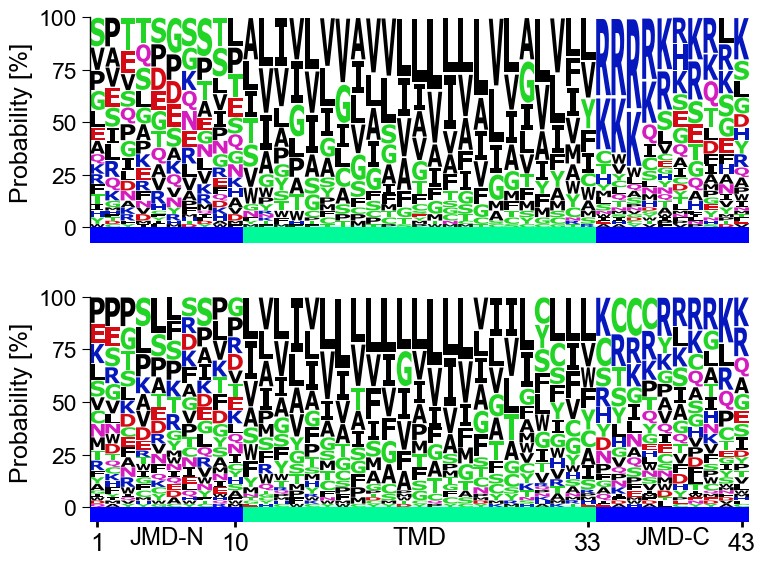

In [2]:
# Two logos: one subplot per group
fig, axes = aal_plot.multi_logo(list_df_logo=[df_logo_pos, df_logo_neg])
print(f"n_subplots: {len(axes)}, positions per logo: {len(df_logo_pos)}")
plt.show()

## Parameter: `list_aal_kws`

`list_aal_kws` is a convenience shortcut that skips the manual `AALogo` step for
every group. Pass a list of dicts -- one per subplot -- each holding the
`AALogo.get_df_logo` arguments for that group (often the same `df_parts` with a
different `label_test`). `AALogoPlot` instantiates `AALogo` internally (using this
plot's `logo_type`) and computes **both** `list_df_logo` and `list_df_logo_info` for
you, so each logo is drawn with its bit-score bar on top. It is mutually exclusive
with `list_df_logo`.

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


n_subplots: 2


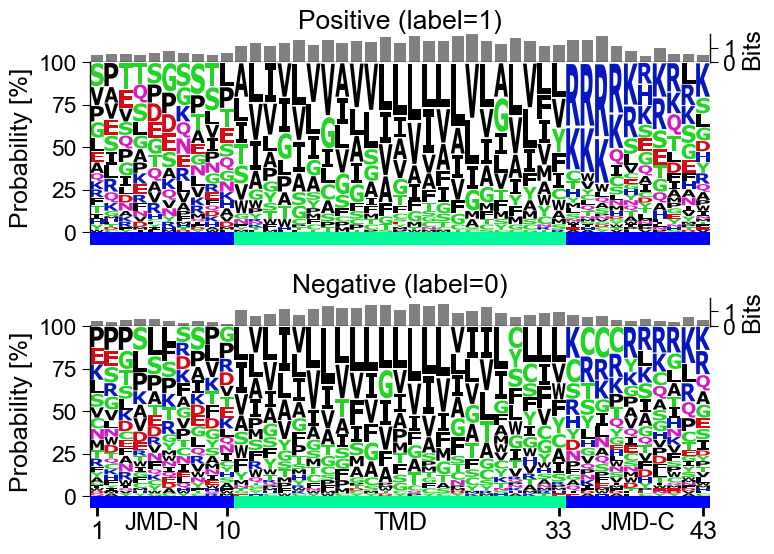

In [3]:
# One-shot: build both logos from df_parts via label_test, no manual AALogo step
fig, axes = aal_plot.multi_logo(
    list_aal_kws=[
        dict(df_parts=df_parts, labels=labels, label_test=1),
        dict(df_parts=df_parts, labels=labels, label_test=0),
    ],
    list_name_data=['Positive (label=1)', 'Negative (label=0)'],
)
print(f"n_subplots: {len(axes)}")
plt.show()

## Parameter: `list_df_logo_info` (bit-score bars)

Pass a list of per-position information-content `Series` (from
`AALogo.get_df_logo_info`), one per group, to render a bit-score bar above each
logo -- the stacked counterpart of `single_logo`'s bar. `info_bar_color` sets the
bar color. The method then returns one `(ax_logo, ax_info)` tuple per group.

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


returns 2 (ax_logo, ax_info) pairs


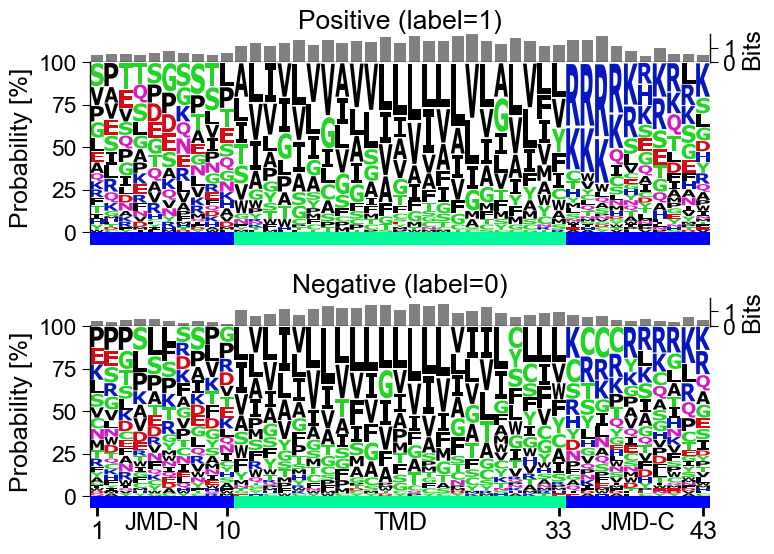

In [4]:
# Precomputed bit-score bars, one per logo
fig, axes = aal_plot.multi_logo(
    list_df_logo=[df_logo_pos, df_logo_neg],
    list_df_logo_info=[df_info_pos, df_info_neg],
    list_name_data=['Positive (label=1)', 'Negative (label=0)'],
    info_bar_color='gray',
)
print(f"returns {len(axes)} (ax_logo, ax_info) pairs")
plt.tight_layout()
plt.show()

## Parameter: `info_bar_ylim` and `height_ratio`

`info_bar_ylim` sets a shared `(min, max)` for every bit-score bar so heights stay
comparable across groups (auto-scaled to the global maximum when `None`).
`height_ratio` sets the `(info_bar, logo)` height proportion of each group.

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


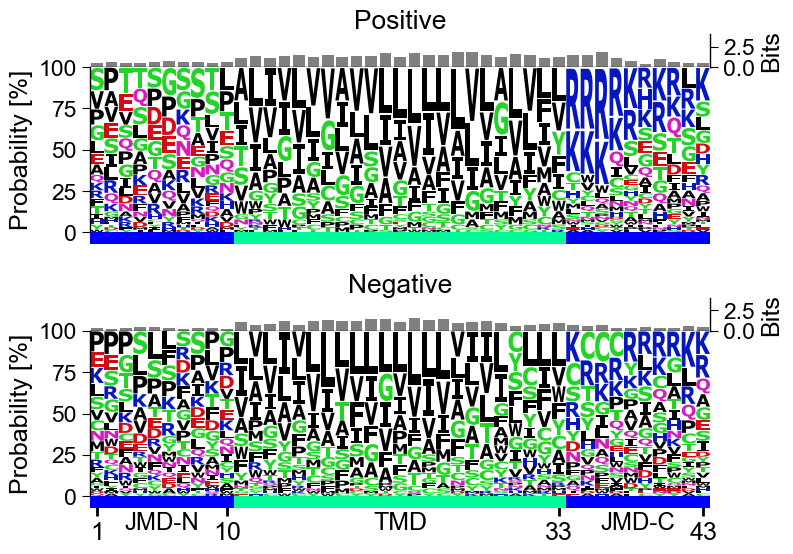

In [5]:
fig, axes = aal_plot.multi_logo(
    list_df_logo=[df_logo_pos, df_logo_neg],
    list_df_logo_info=[df_info_pos, df_info_neg],
    list_name_data=['Positive', 'Negative'],
    info_bar_ylim=(0, 4),
    height_ratio=(1, 5),
)
plt.tight_layout()
plt.show()

## Parameter: `list_name_data` and `list_name_data_color`

`list_name_data` annotates each subplot with a label. Length must match `list_df_logo`.
`list_name_data_color` sets the color — either a single string (applies to all)
or a list with one color per subplot.

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


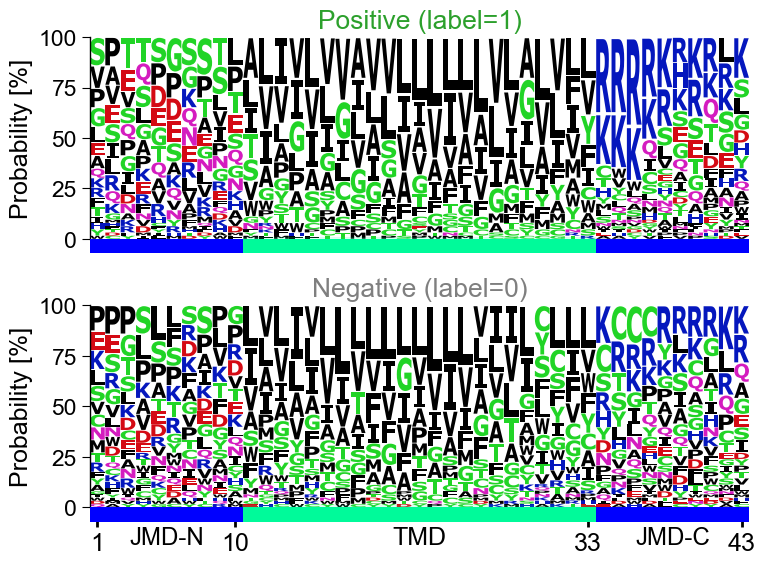

In [6]:
fig, axes = aal_plot.multi_logo(
    list_df_logo=[df_logo_pos, df_logo_neg],
    list_name_data=['Positive (label=1)', 'Negative (label=0)'],
    list_name_data_color=['tab:green', 'tab:gray'],
)
plt.show()

## Parameter: `name_data_pos`

Controls where the label is placed on each subplot's axes.
Uses `ax.transAxes` coordinates, so the same position applies to every subplot.

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


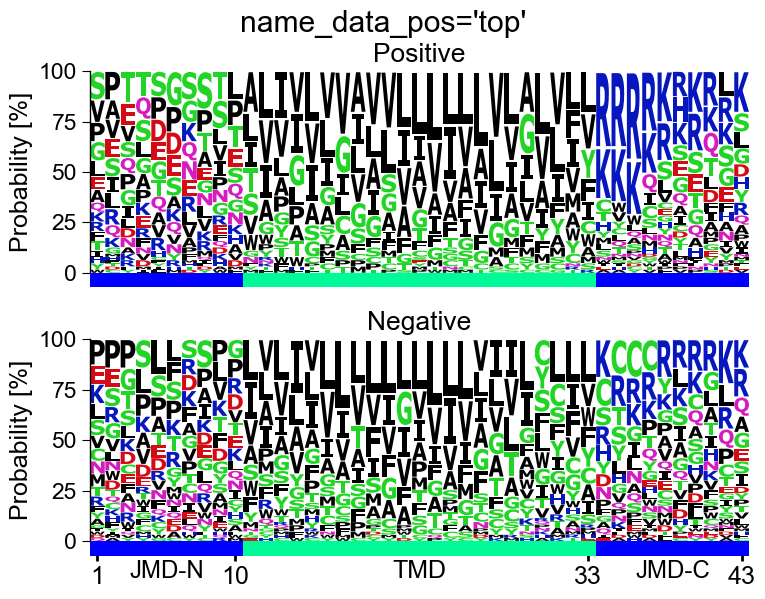

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


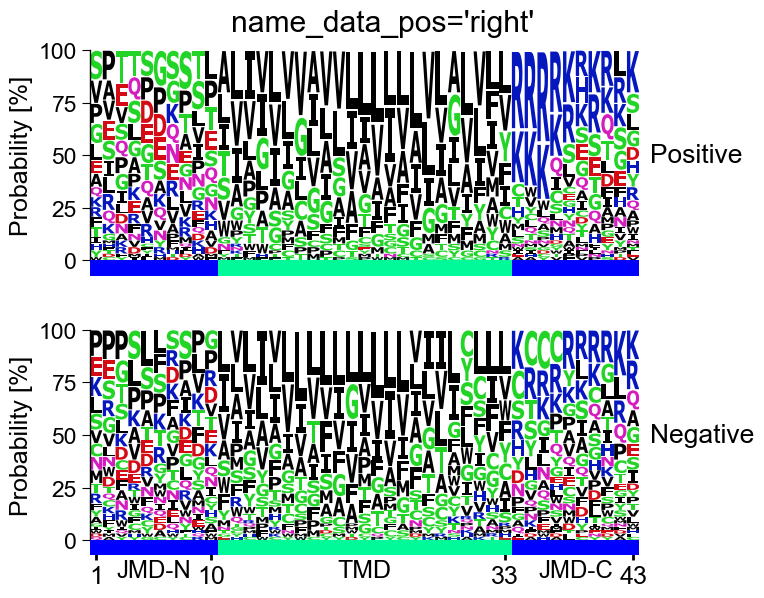

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


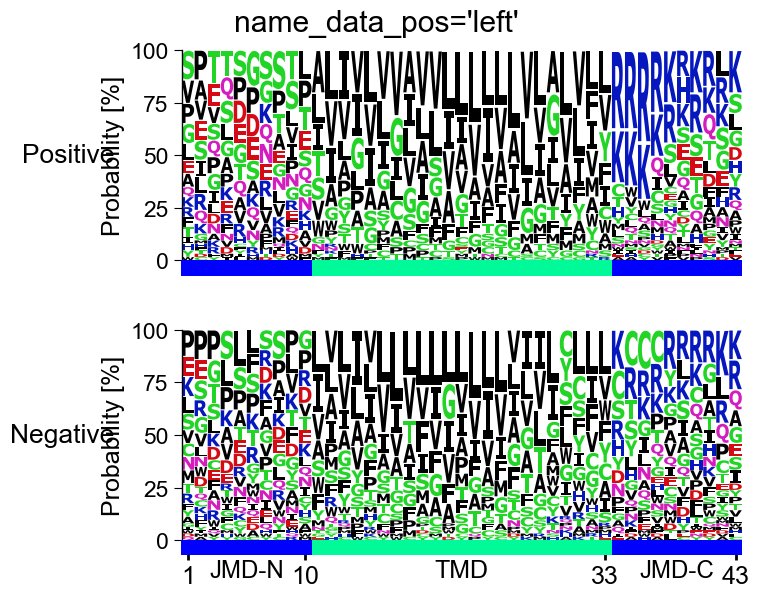

In [7]:
for pos in ['top', 'right', 'left']:
    fig, axes = aal_plot.multi_logo(
        list_df_logo=[df_logo_pos, df_logo_neg],
        list_name_data=['Positive', 'Negative'],
        name_data_pos=pos,
    )
    fig.suptitle(f"name_data_pos='{pos}'", y=1.01)
    plt.show()

## Parameter: `figsize_per_logo`

Sets the `(width, height)` of each individual subplot in inches.
Total figure height = `figsize_per_logo[1] * len(list_df_logo)`.

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


figsize_per_logo height=2: total fig height = 4.0 in


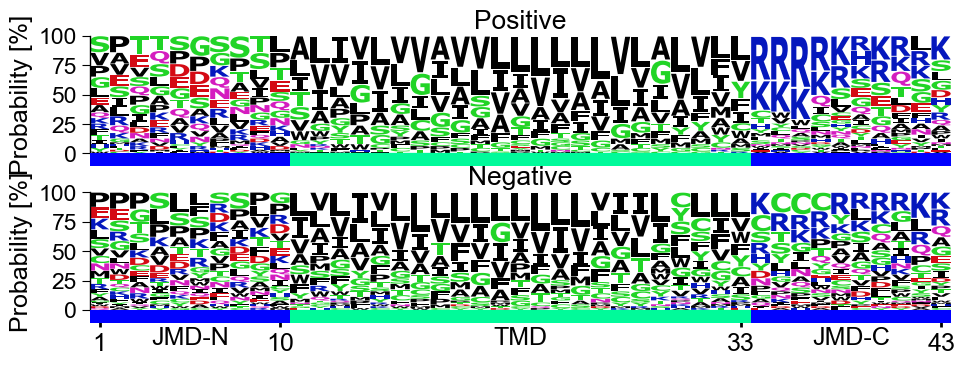

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


figsize_per_logo height=4: total fig height = 8.0 in


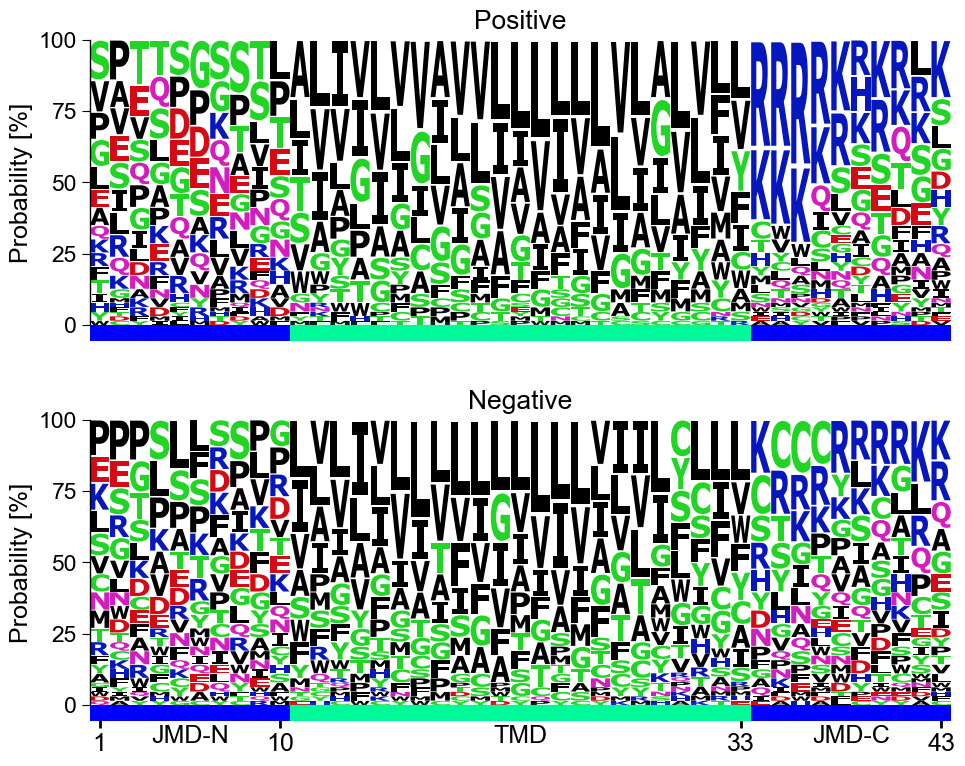

In [8]:
for h in [2, 4]:
    fig, axes = aal_plot.multi_logo(
        list_df_logo=[df_logo_pos, df_logo_neg],
        list_name_data=['Positive', 'Negative'],
        figsize_per_logo=(10, h),
    )
    print(f"figsize_per_logo height={h}: total fig height = {fig.get_size_inches()[1]:.1f} in")
    plt.show()

## Parameter: `logo_color_scheme` and `logo_stack_order`

`logo_color_scheme` is passed directly to `logomaker.Logo`. Common options:
`'weblogo_protein'` (default), `'chemistry'`, `'hydrophobicity'`.

`logo_stack_order` controls letter stacking within each column:
`'big_on_top'` (default), `'small_on_top'`, `'fixed'`.

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


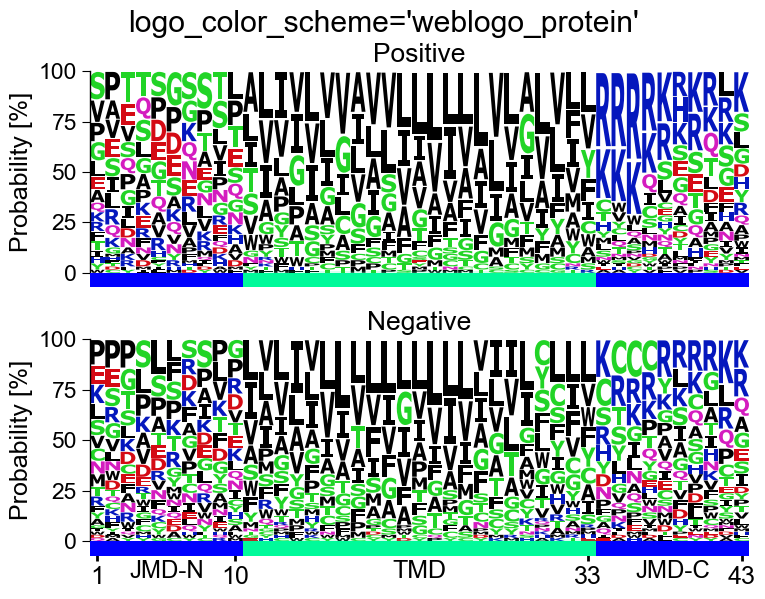

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


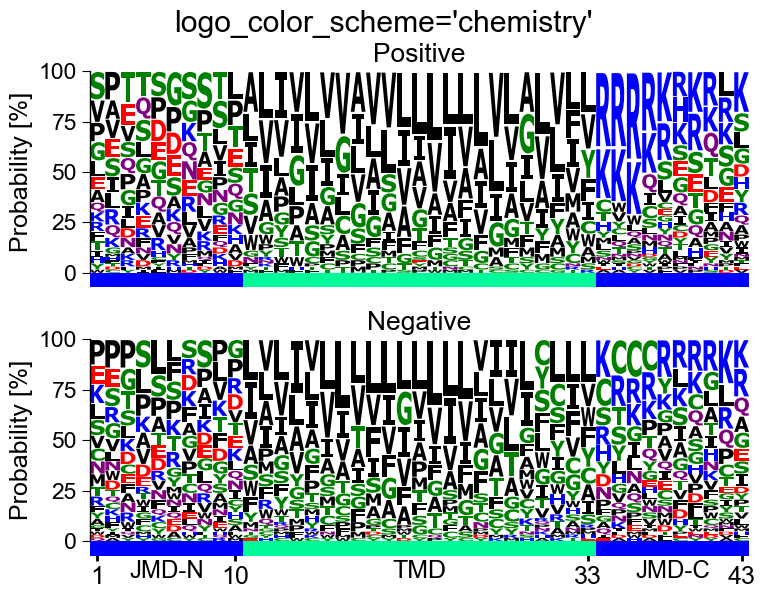

In [9]:
for scheme in ['weblogo_protein', 'chemistry']:
    fig, axes = aal_plot.multi_logo(
        list_df_logo=[df_logo_pos, df_logo_neg],
        list_name_data=['Positive', 'Negative'],
        logo_color_scheme=scheme,
    )
    fig.suptitle(f"logo_color_scheme='{scheme}'", y=1.01)
    plt.show()

## Parameter: `highlight_tmd_area` and `highlight_alpha`

`highlight_tmd_area=True` (default) shades the TMD region in every subplot.
`highlight_alpha` controls the opacity of the shading (0 = invisible, 1 = opaque).

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


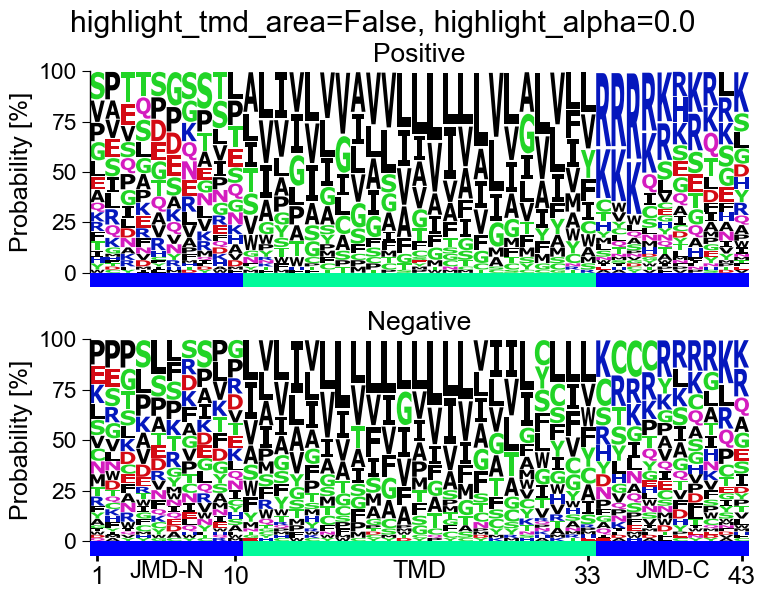

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


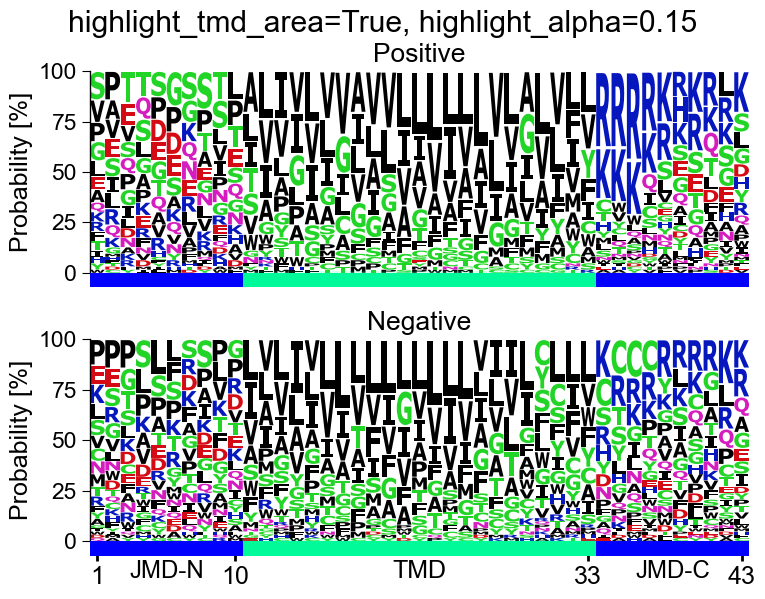

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


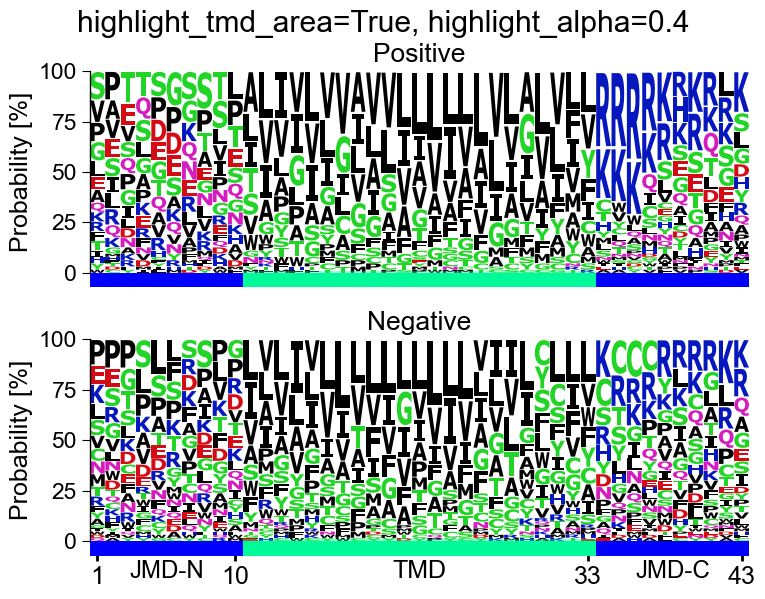

In [10]:
for alpha in [0.0, 0.15, 0.4]:
    fig, axes = aal_plot.multi_logo(
        list_df_logo=[df_logo_pos, df_logo_neg],
        list_name_data=['Positive', 'Negative'],
        highlight_tmd_area=alpha > 0,
        highlight_alpha=alpha if alpha > 0 else 0.15,
    )
    fig.suptitle(f"highlight_tmd_area={alpha > 0}, highlight_alpha={alpha}", y=1.01)
    plt.show()

## Parameter: `tmd_color` and `jmd_color`

Set the color of the TMD and JMD part bar, x-tick marks, and TMD highlight rectangle
across all subplots.

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


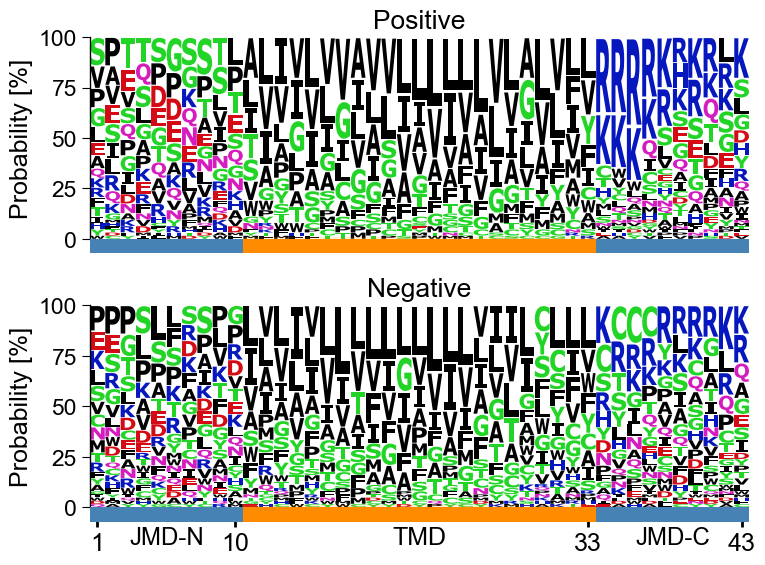

In [11]:
fig, axes = aal_plot.multi_logo(
    list_df_logo=[df_logo_pos, df_logo_neg],
    list_name_data=['Positive', 'Negative'],
    tmd_color='darkorange',
    jmd_color='steelblue',
)
plt.show()

## Parameter: `start`

Sets the residue number of the first position. Shifts x-tick **labels** on the bottom
subplot only — does not affect positions or highlight coordinates.

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


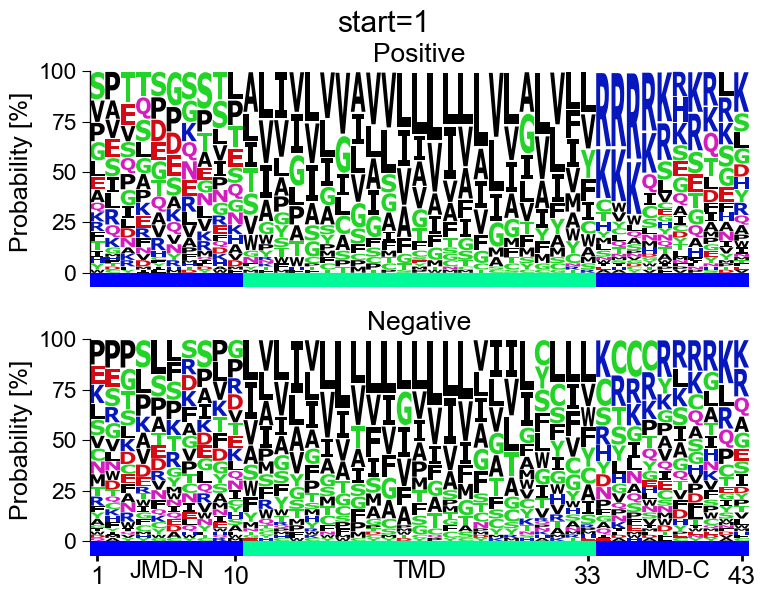

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


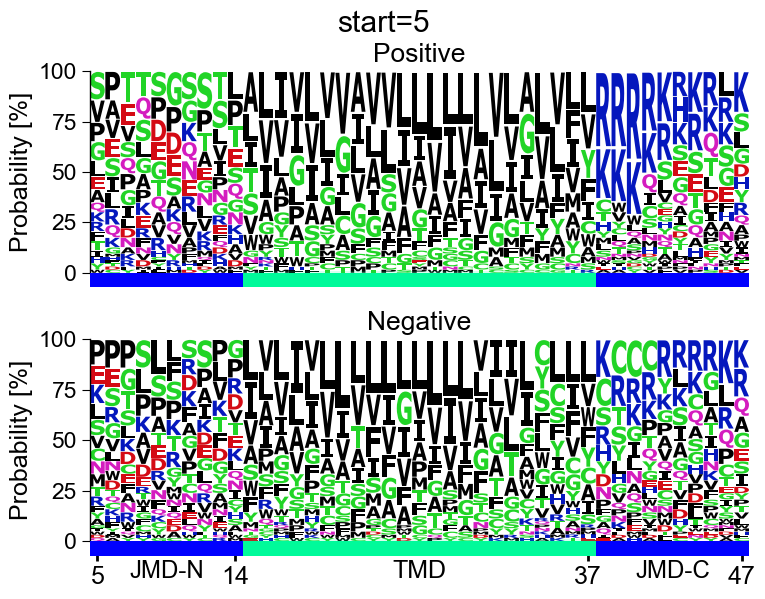

In [12]:
for start in [1, 5]:
    fig, axes = aal_plot.multi_logo(
        list_df_logo=[df_logo_pos, df_logo_neg],
        list_name_data=['Positive', 'Negative'],
        start=start,
    )
    fig.suptitle(f"start={start}", y=1.01)
    plt.show()

## Parameter: `weight_tmd_jmd` and `fontsize_tmd_jmd`

These control the appearance of the 'JMD-N', 'TMD', 'JMD-C' text labels,
which are drawn only on the **bottom** subplot.

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


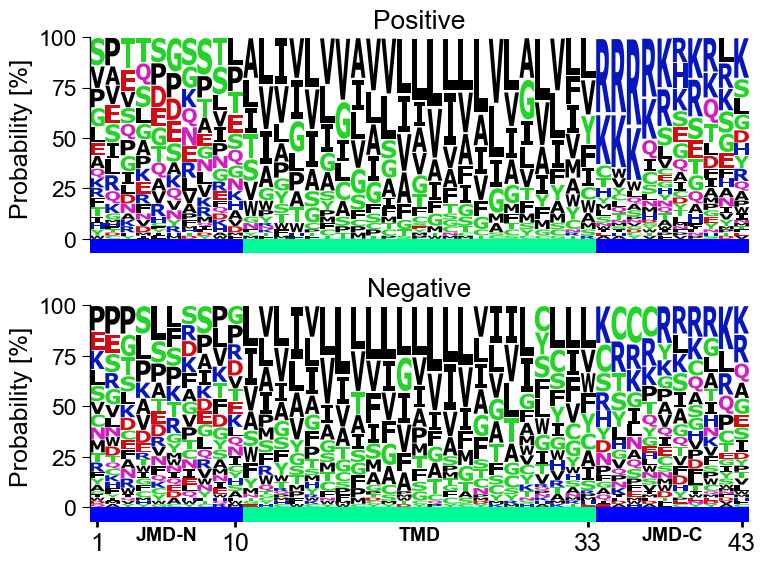

In [13]:
fig, axes = aal_plot.multi_logo(
    list_df_logo=[df_logo_pos, df_logo_neg],
    list_name_data=['Positive', 'Negative'],
    weight_tmd_jmd='bold',
    fontsize_tmd_jmd=14,
)
plt.show()

## Parameter: `target_p1_site`

When set, replaces the standard JMD/TMD x-axis on **every** subplot with
P-site notation (P2, P1, P1', P2', ...). The value is the 0-based position
index of the P1 cleavage site.

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


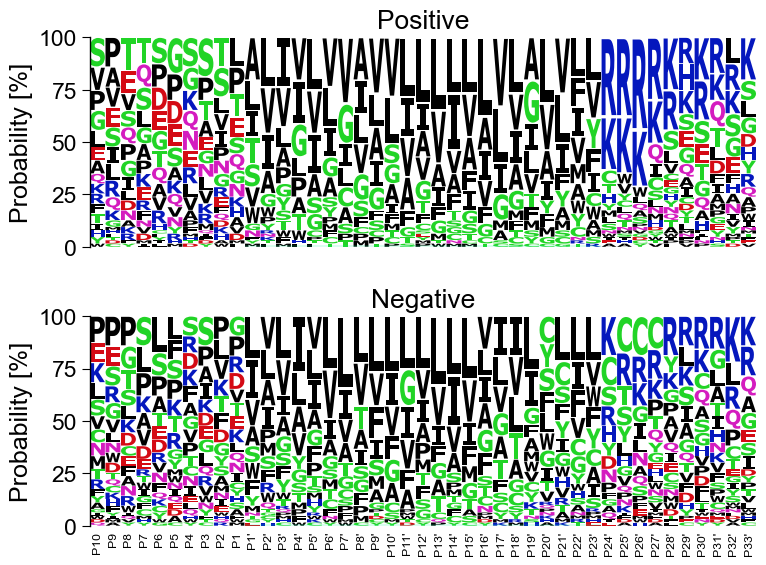

In [14]:
# P1 site at position index 10 (start of TMD in a 10+20+10 layout)
fig, axes = aal_plot.multi_logo(
    list_df_logo=[df_logo_pos, df_logo_neg],
    list_name_data=['Positive', 'Negative'],
    target_p1_site=10,
)
plt.show()

## Shared y-axis

All subplots automatically share the same y-axis maximum, computed from the
maximum per-position sum across all logos. This makes group comparisons visually fair.

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


y-axis limits per subplot: [(np.float64(0.0), np.float64(100.00000000000003)), (np.float64(0.0), np.float64(100.00000000000003))]
All equal: True


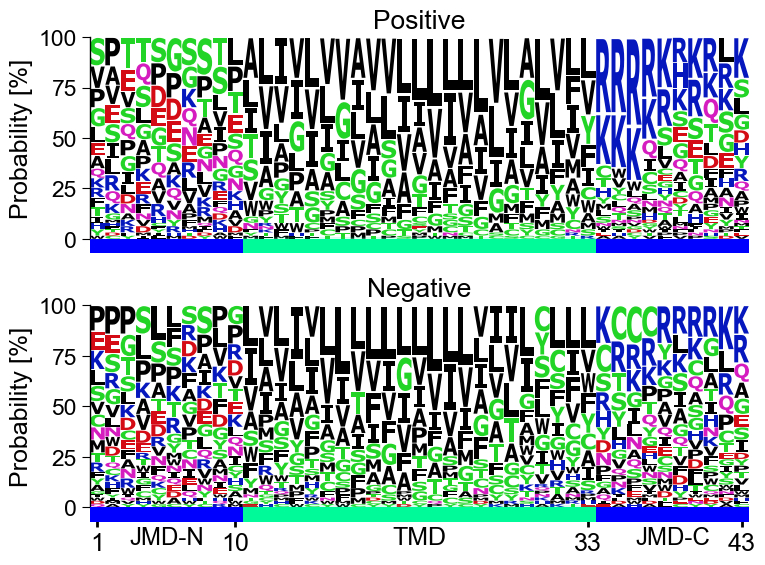

In [15]:
fig, axes = aal_plot.multi_logo(
    list_df_logo=[df_logo_pos, df_logo_neg],
    list_name_data=['Positive', 'Negative'],
)
ylims = [ax.get_ylim() for ax in axes]
print(f"y-axis limits per subplot: {ylims}")
print(f"All equal: {len(set(ylims)) == 1}")
plt.show()

**Further parameters.** ``AALogoPlot.multi_logo`` also accepts fine-tuning knobs for the letter geometry, stacking, annotation styling, and x-tick appearance: ``fontsize_labels`` (axis-label font size), ``name_data_fontsize`` (font size of the name annotations), ``logo_font_name`` (font for the amino-acid letters), ``logo_stack_order`` (letter stacking order within each column), ``logo_width`` (relative width of each letter column, 0 to 1), ``logo_vpad`` / ``logo_vsep`` (vertical padding / separation between stacked letters), and ``xtick_size`` / ``xtick_width`` / ``xtick_length`` (font size / line width / length of the x-tick marks, bottom subplot). The cell below passes all of them explicitly.

Plotting 2 logos (TMD length=23, JMD-N=10, JMD-C=10)


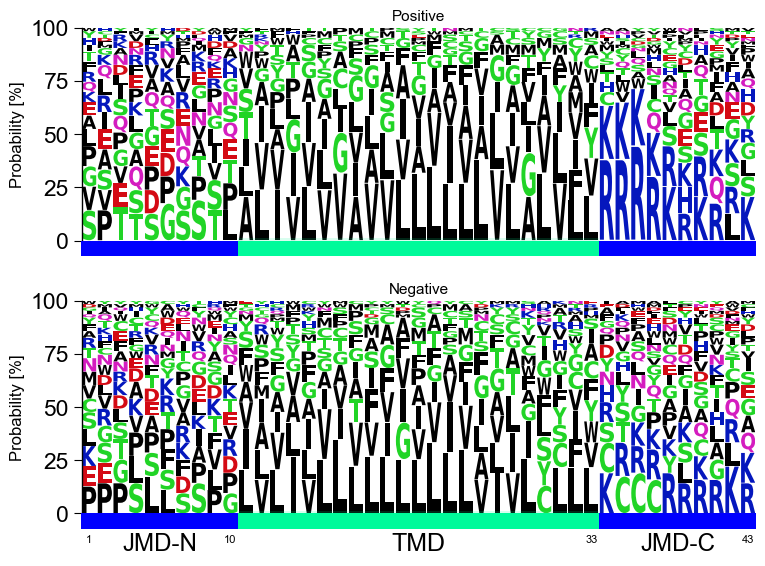

In [16]:
# Fine-tuning: letter geometry, stacking, annotation + x-tick styling
fig, axes = aal_plot.multi_logo(
    list_df_logo=[df_logo_pos, df_logo_neg],
    list_name_data=['Positive', 'Negative'],
    fontsize_labels=12,               # axis-label font size
    name_data_fontsize=11,            # font size of the name annotations
    logo_font_name='DejaVu Sans',     # font for the amino-acid letters
    logo_stack_order='small_on_top',  # stacking order within each column
    logo_width=0.9,                   # relative width of each letter column (0-1)
    logo_vpad=0.02,                   # vertical padding between stacked letters
    logo_vsep=0.0,                    # vertical separation between stacked letters
    xtick_size=8,                     # x-tick label font size (bottom subplot)
    xtick_width=1.5,                  # line width of x-tick marks
    xtick_length=8,                   # length of x-tick marks in points
)
plt.tight_layout()
plt.show()